# DPL Hierarchical Classifier — Confidence Scores

The hierarchical model produces **two confidence scores** at each step:

```
Description
    │
    ▼  Level 1  →  P(group)        e.g. 0.97  "Finance & Treasury"
    │
    ▼  Level 2  →  P(tag | group)  e.g. 0.88  "DPL035"
    │
    ▼  Joint    →  P(group) × P(tag | group)  e.g. 0.97 × 0.88 = 0.85
```

The **joint confidence** is the most conservative and correct overall confidence measure.

## Structure
1. Load dataset & hierarchy  
2. Train Level 1 — calibrated group classifier  
3. Train Level 2 — calibrated classifiers per group  
4. Build `HierarchicalDPLClassifier` with confidence  
5. Evaluate — accuracy, F1, confidence breakdown  
6. Confidence threshold analysis  
7. Group-level confidence heatmap  
8. Save models  
9. Inference helper  

## 1. Load Dataset & Define Hierarchy

In [1]:
import pandas as pd
import numpy as np
import json, os, time, warnings
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

DATASETS_DIR = "datasets"
train_df    = pd.read_csv(f"{DATASETS_DIR}/dpl_train.csv")
val_df      = pd.read_csv(f"{DATASETS_DIR}/dpl_val.csv")
test_df     = pd.read_csv(f"{DATASETS_DIR}/dpl_test.csv")
trainval_df = pd.concat([train_df, val_df], ignore_index=True)

HIERARCHY = {
    "Finance & Treasury": [
        "DPL005","DPL006","DPL013","DPL014","DPL026",
        "DPL027","DPL035","DPL043","DPL057","DPL058",
        "DPL067","DPL075","DPL076",
    ],
    "Staff & Employment": [
        "DPL048","DPL051","DPL052","DPL062",
        "DPL068","DPL070","DPL073",
    ],
    "Operational & Administrative": [
        "DPL001","DPL008","DPL016","DPL037","DPL041",
        "DPL046","DPL047","DPL054","DPL055","DPL061",
        "DPL063","DPL064","DPL065","DPL069",
    ],
    "Professional & External Services": [
        "DPL003","DPL009","DPL012","DPL038","DPL049",
    ],
    "Revenue & Income": [
        "DPL024","DPL030","DPL045","DPL066","DPL071","DPL072",
    ],
    "Gains, Losses & Adjustments": [
        "DPL017","DPL018","DPL019","DPL020","DPL021",
        "DPL022","DPL023","DPL028","DPL029",
    ],
    "Asset & Accounting Adjustments": [
        "DPL002","DPL010","DPL032","DPL042","DPL050",
    ],
    "Regulatory, Tax & Compliance": [
        "DPL015","DPL025","DPL031","DPL036","DPL053",
    ],
    "Miscellaneous": [
        "DPL004","DPL007","DPL011","DPL033","DPL034",
        "DPL039","DPL040","DPL044","DPL056","DPL059",
        "DPL060","DPL074",
    ],
}

TAG_TO_GROUP = {tag: grp for grp, tags in HIERARCHY.items() for tag in tags}
for df in [train_df, val_df, test_df, trainval_df]:
    df["group"] = df["dpl_tag"].map(TAG_TO_GROUP)
trainval_df = trainval_df.dropna(subset=["group"])
test_df     = test_df.dropna(subset=["group"])

print(f"Train+Val: {len(trainval_df):,}  |  Test: {len(test_df):,}")
print(f"Groups: {len(HIERARCHY)}  |  Tags: {len(TAG_TO_GROUP)}")

Train+Val: 12,851  |  Test: 2,272
Groups: 9  |  Tags: 76


## 2. Train Level 1 — Calibrated Group Classifier

In [2]:
def build_calibrated_svc(C=1.0, cv=3):
    """TF-IDF features + CalibratedClassifierCV(LinearSVC) for probability output."""
    return Pipeline([
        ("features", FeatureUnion([
            ("word", TfidfVectorizer(
                analyzer="word", ngram_range=(1, 3),
                min_df=2, max_features=80_000, sublinear_tf=True,
            )),
            ("char", TfidfVectorizer(
                analyzer="char_wb", ngram_range=(3, 5),
                min_df=3, max_features=40_000, sublinear_tf=True,
            )),
        ])),
        ("clf", CalibratedClassifierCV(
            LinearSVC(C=C, max_iter=2000, dual="auto"),
            method="sigmoid", cv=cv,
        )),
    ])


le_group = LabelEncoder()
le_group.fit(sorted(HIERARCHY.keys()))

X_tv       = trainval_df["description"].tolist()
y_tv_grp   = le_group.transform(trainval_df["group"])
X_test     = test_df["description"].tolist()
y_test_grp = le_group.transform(test_df["group"])
true_tags  = test_df["dpl_tag"].tolist()

t0 = time.time()
l1_clf = build_calibrated_svc(C=1.0, cv=3)
l1_clf.fit(X_tv, y_tv_grp)
print(f"Level 1 training: {time.time()-t0:.1f}s")

l1_probs      = l1_clf.predict_proba(X_test)     # (n, 9)
l1_pred_ids   = l1_probs.argmax(axis=1)
l1_pred_names = le_group.inverse_transform(l1_pred_ids)
l1_conf       = l1_probs.max(axis=1)

l1_acc = accuracy_score(y_test_grp, l1_pred_ids)
l1_f1  = f1_score(y_test_grp, l1_pred_ids, average="weighted", zero_division=0)
print(f"Level 1 accuracy : {l1_acc:.4f}  |  Weighted F1: {l1_f1:.4f}")
print(f"Level 1 mean confidence: {l1_conf.mean():.4f}")

Level 1 training: 1.7s
Level 1 accuracy : 1.0000  |  Weighted F1: 1.0000
Level 1 mean confidence: 0.9962


## 3. Train Level 2 — Calibrated Classifier Per Group

In [3]:
l2_clfs = {}   # group → fitted pipeline
l2_les  = {}   # group → LabelEncoder for DPL tags

t0 = time.time()
for group, tags in HIERARCHY.items():
    mask   = trainval_df["group"] == group
    grp_df = trainval_df[mask]

    if grp_df.empty or grp_df["dpl_tag"].nunique() < 2:
        print(f"  SKIP {group}")
        continue

    le_tag = LabelEncoder()
    le_tag.fit(sorted(grp_df["dpl_tag"].unique()))

    clf = build_calibrated_svc(C=2.0, cv=3)
    clf.fit(grp_df["description"].tolist(), le_tag.transform(grp_df["dpl_tag"]))

    l2_clfs[group] = clf
    l2_les[group]  = le_tag
    print(f"  ✓  {group:<40}  {len(le_tag.classes_):>2} tags  {len(grp_df):>5} samples")

print(f"\nLevel 2 total training: {time.time()-t0:.1f}s")

  ✓  Finance & Treasury                        13 tags   2210 samples
  ✓  Staff & Employment                         7 tags   1190 samples
  ✓  Operational & Administrative              14 tags   2380 samples
  ✓  Professional & External Services           5 tags    850 samples
  ✓  Revenue & Income                           6 tags    958 samples
  ✓  Gains, Losses & Adjustments                9 tags   1530 samples
  ✓  Asset & Accounting Adjustments             5 tags    850 samples
  ✓  Regulatory, Tax & Compliance               5 tags    847 samples
  ✓  Miscellaneous                             12 tags   2036 samples

Level 2 total training: 2.2s


## 4. `HierarchicalDPLClassifier` with Confidence

In [4]:
class HierarchicalDPLClassifier:
    """
    Two-stage classifier with full confidence breakdown.

    predict_detailed() returns for each description:
      {
        'description'      : str,
        'group'            : str,    # predicted group
        'group_confidence' : float,  # P(group)
        'tag'              : str,    # predicted DPL tag
        'tag_confidence'   : float,  # P(tag | group)
        'joint_confidence' : float,  # P(group) × P(tag | group)
        'top_k_tags'       : list,   # top-K within predicted group
        'accepted'         : bool    # joint_confidence >= threshold
      }
    """

    def __init__(self, l1_clf, le_group, l2_clfs, l2_les):
        self.l1_clf   = l1_clf
        self.le_group = le_group
        self.l2_clfs  = l2_clfs
        self.l2_les   = l2_les

    def predict(self, descriptions: list[str]) -> list[str]:
        return [r["tag"] for r in self.predict_detailed(descriptions)]

    def predict_detailed(self,
                         descriptions: list[str],
                         top_k: int = 3,
                         threshold: float = 0.0) -> list[dict]:
        # ── Level 1: group probabilities ────────────────────────────────────
        l1_probs      = self.l1_clf.predict_proba(descriptions)   # (n, 9)
        l1_pred_ids   = l1_probs.argmax(axis=1)
        l1_pred_names = self.le_group.inverse_transform(l1_pred_ids)
        l1_conf       = l1_probs.max(axis=1)

        results = [None] * len(descriptions)

        # ── Level 2: batch by predicted group ───────────────────────────────
        for group in set(l1_pred_names):
            indices = [i for i, g in enumerate(l1_pred_names) if g == group]
            batch   = [descriptions[i] for i in indices]

            if group not in self.l2_clfs:
                for i in indices:
                    results[i] = {
                        "description":      descriptions[i],
                        "group":            group,
                        "group_confidence": round(float(l1_conf[i]), 4),
                        "tag":              "UNKNOWN",
                        "tag_confidence":   0.0,
                        "joint_confidence": 0.0,
                        "top_k_tags":       [],
                        "accepted":         False,
                    }
                continue

            l2_probs    = self.l2_clfs[group].predict_proba(batch)   # (m, n_tags)
            l2_pred_ids = l2_probs.argmax(axis=1)
            l2_conf     = l2_probs.max(axis=1)
            le_tag      = self.l2_les[group]

            for j, i in enumerate(indices):
                g_conf    = float(l1_conf[i])
                t_conf    = float(l2_conf[j])
                j_conf    = round(g_conf * t_conf, 4)
                top_idxs  = np.argsort(l2_probs[j])[::-1][:top_k]
                top_tags  = [{"tag": le_tag.classes_[idx],
                               "tag_confidence": round(float(l2_probs[j][idx]), 4),
                               "joint_confidence": round(g_conf * float(l2_probs[j][idx]), 4)}
                              for idx in top_idxs]

                results[i] = {
                    "description":      descriptions[i],
                    "group":            group,
                    "group_confidence": round(g_conf, 4),
                    "tag":              le_tag.classes_[l2_pred_ids[j]],
                    "tag_confidence":   round(t_conf, 4),
                    "joint_confidence": j_conf,
                    "top_k_tags":       top_tags,
                    "accepted":         j_conf >= threshold,
                }

        return results


hier_clf = HierarchicalDPLClassifier(l1_clf, le_group, l2_clfs, l2_les)
print("HierarchicalDPLClassifier (with confidence) ready.")

HierarchicalDPLClassifier (with confidence) ready.


## 5. Evaluate

In [5]:
t0 = time.time()
detailed = hier_clf.predict_detailed(X_test, top_k=3)
infer_time = time.time() - t0

hier_preds  = [r["tag"] for r in detailed]
grp_confs   = np.array([r["group_confidence"]  for r in detailed])
tag_confs   = np.array([r["tag_confidence"]    for r in detailed])
joint_confs = np.array([r["joint_confidence"]  for r in detailed])

hier_acc = accuracy_score(true_tags, hier_preds)
hier_f1  = f1_score(true_tags, hier_preds, average="weighted", zero_division=0)

print(f"Inference time        : {infer_time:.2f}s")
print(f"Accuracy              : {hier_acc:.4f}")
print(f"Weighted F1           : {hier_f1:.4f}")
print()
print(f"Mean group confidence : {grp_confs.mean():.4f}")
print(f"Mean tag confidence   : {tag_confs.mean():.4f}")
print(f"Mean joint confidence : {joint_confs.mean():.4f}")
print()
print(f"Joint < 0.50          : {(joint_confs < 0.50).sum()} ({100*(joint_confs<0.50).mean():.1f}%)")
print(f"Joint < 0.80          : {(joint_confs < 0.80).sum()} ({100*(joint_confs<0.80).mean():.1f}%)")

Inference time        : 0.26s
Accuracy              : 0.9996
Weighted F1           : 0.9996

Mean group confidence : 0.9962
Mean tag confidence   : 0.9790
Mean joint confidence : 0.9754

Joint < 0.50          : 1 (0.0%)
Joint < 0.80          : 15 (0.7%)


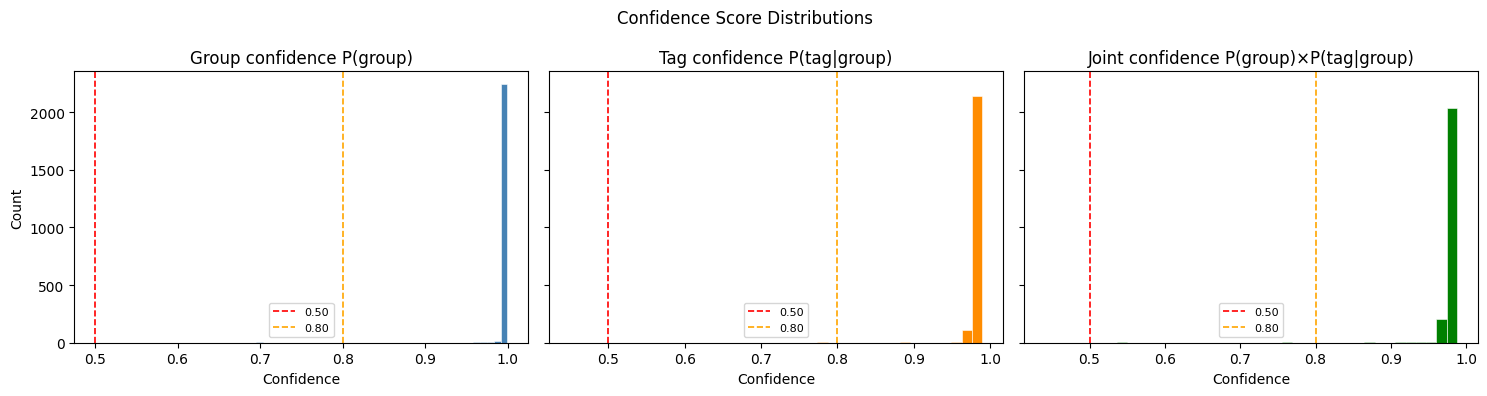

In [6]:
# Confidence distributions side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
pairs = [
    (grp_confs,   "Group confidence P(group)",      "steelblue"),
    (tag_confs,   "Tag confidence P(tag|group)",    "darkorange"),
    (joint_confs, "Joint confidence P(group)×P(tag|group)", "green"),
]
for ax, (conf, title, color) in zip(axes, pairs):
    ax.hist(conf, bins=40, color=color, edgecolor="white", linewidth=0.4)
    ax.axvline(0.50, color="red",    linestyle="--", linewidth=1.2, label="0.50")
    ax.axvline(0.80, color="orange", linestyle="--", linewidth=1.2, label="0.80")
    ax.set_title(title)
    ax.set_xlabel("Confidence")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Count")
plt.suptitle("Confidence Score Distributions")
plt.tight_layout()
plt.show()

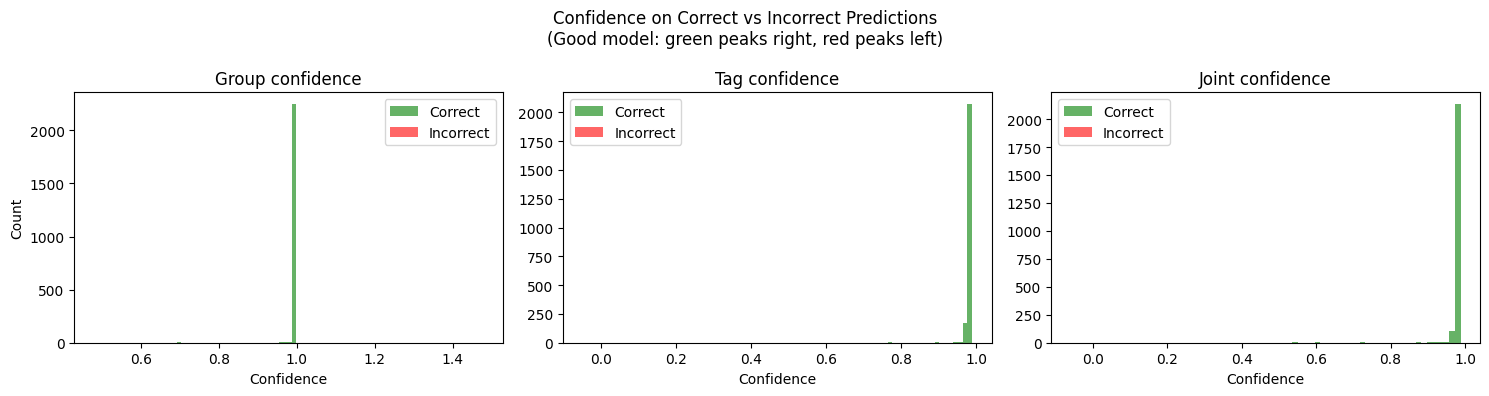

In [7]:
# Accuracy when correct vs when wrong — do confidence scores discriminate?
correct_mask  = np.array(hier_preds) == np.array(true_tags)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (conf, title) in zip(axes, [
    (grp_confs,   "Group confidence"),
    (tag_confs,   "Tag confidence"),
    (joint_confs, "Joint confidence"),
]):
    ax.hist(conf[correct_mask],  bins=30, alpha=0.6, label="Correct",   color="green")
    ax.hist(conf[~correct_mask], bins=30, alpha=0.6, label="Incorrect", color="red")
    ax.set_title(title)
    ax.set_xlabel("Confidence")
    ax.legend()
axes[0].set_ylabel("Count")
plt.suptitle("Confidence on Correct vs Incorrect Predictions\n"
             "(Good model: green peaks right, red peaks left)")
plt.tight_layout()
plt.show()

## 6. Confidence Threshold Analysis

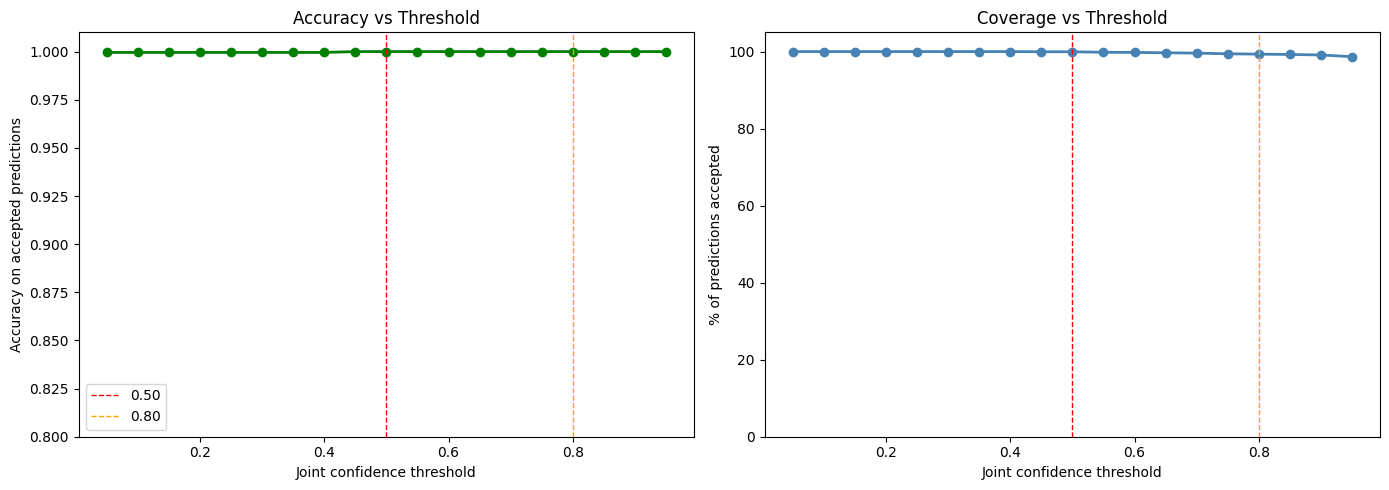


 Threshold   Coverage   Accuracy   Abstentions
------------------------------------------------
      0.50     100.0%     1.0000             1
      0.80      99.3%     1.0000            15


In [8]:
true_arr = np.array(true_tags)
pred_arr = np.array(hier_preds)

thresholds = np.arange(0.05, 1.0, 0.05)
rows = []
for t in thresholds:
    mask = joint_confs >= t
    if mask.sum() == 0:
        break
    rows.append({
        "threshold":   t,
        "coverage":    mask.mean(),
        "accuracy":    accuracy_score(true_arr[mask], pred_arr[mask]),
        "abstentions": (~mask).sum(),
    })
thresh_df = pd.DataFrame(rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(thresh_df["threshold"], thresh_df["accuracy"], "o-", color="green", linewidth=2)
ax1.axvline(0.50, color="red",    linestyle="--", linewidth=1, label="0.50")
ax1.axvline(0.80, color="orange", linestyle="--", linewidth=1, label="0.80")
ax1.set_xlabel("Joint confidence threshold")
ax1.set_ylabel("Accuracy on accepted predictions")
ax1.set_title("Accuracy vs Threshold")
ax1.set_ylim(0.8, 1.01); ax1.legend()

ax2.plot(thresh_df["threshold"], thresh_df["coverage"] * 100, "o-", color="steelblue", linewidth=2)
ax2.axvline(0.50, color="red",    linestyle="--", linewidth=1)
ax2.axvline(0.80, color="orange", linestyle="--", linewidth=1)
ax2.set_xlabel("Joint confidence threshold")
ax2.set_ylabel("% of predictions accepted")
ax2.set_title("Coverage vs Threshold")
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()

# Print key operating points
print(f"\n{'Threshold':>10}  {'Coverage':>9}  {'Accuracy':>9}  {'Abstentions':>12}")
print("-" * 48)
for _, row in thresh_df[thresh_df["threshold"].isin([0.50, 0.60, 0.70, 0.80, 0.90])].iterrows():
    print(f"{row['threshold']:>10.2f}  {row['coverage']:>9.1%}  "
          f"{row['accuracy']:>9.4f}  {int(row['abstentions']):>12}")

## 7. Group-Level Confidence Heatmap

Group                                       Count   Accuracy   Mean Joint Conf
------------------------------------------------------------------------------
  Asset & Accounting Adjustments              150     1.0000            0.9763  ████████████████████
  Gains, Losses & Adjustments                 270     1.0000            0.9729  ████████████████████
  Miscellaneous                               361     1.0000            0.9774  ████████████████████
  Operational & Administrative                420     1.0000            0.9776  ████████████████████
  Professional & External Services            150     1.0000            0.9706  ████████████████████
  Revenue & Income                            170     1.0000            0.9745  ████████████████████
  Regulatory, Tax & Compliance                151     1.0000            0.9755  ████████████████████
  Staff & Employment                          210     1.0000            0.9771  ████████████████████
  Finance & Treasury              

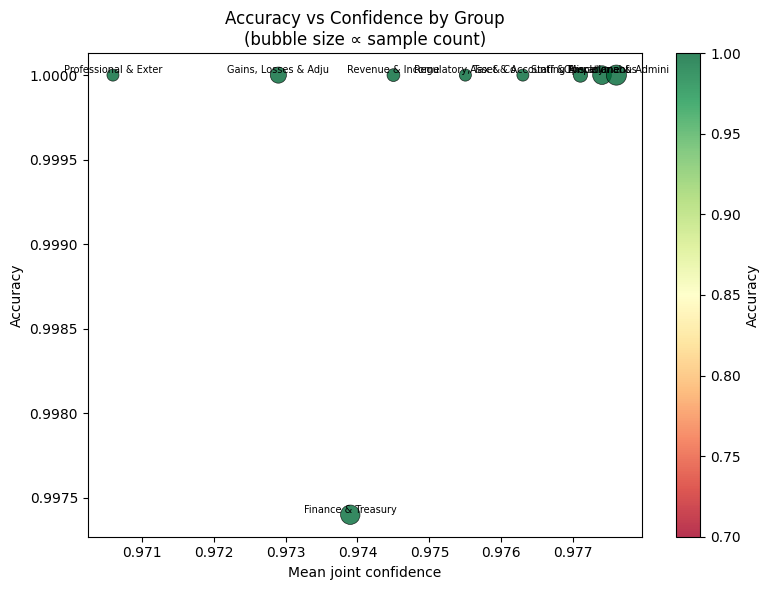

In [9]:
# Mean joint confidence and accuracy per TRUE group
test_df_copy = test_df.copy()
test_df_copy["predicted_tag"]     = hier_preds
test_df_copy["joint_confidence"]  = joint_confs
test_df_copy["correct"]           = test_df_copy["dpl_tag"] == test_df_copy["predicted_tag"]

grp_summary = test_df_copy.groupby("group").agg(
    mean_joint_conf = ("joint_confidence", "mean"),
    accuracy        = ("correct", "mean"),
    count           = ("dpl_tag", "count"),
).round(4).sort_values("accuracy", ascending=False)

print(f"{'Group':<42} {'Count':>6}  {'Accuracy':>9}  {'Mean Joint Conf':>16}")
print("-" * 78)
for grp, row in grp_summary.iterrows():
    bar = "█" * int(row["accuracy"] * 20)
    print(f"  {grp:<40} {int(row['count']):>6}  {row['accuracy']:>9.4f}  {row['mean_joint_conf']:>16.4f}  {bar}")

# Heatmap: accuracy vs mean confidence per group
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    grp_summary["mean_joint_conf"],
    grp_summary["accuracy"],
    s=grp_summary["count"] * 0.5,
    c=grp_summary["accuracy"],
    cmap="RdYlGn", vmin=0.7, vmax=1.0,
    edgecolors="black", linewidths=0.5, alpha=0.8,
)
for grp, row in grp_summary.iterrows():
    ax.annotate(grp[:20], (row["mean_joint_conf"], row["accuracy"]),
                fontsize=7, ha="center", va="bottom")
ax.set_xlabel("Mean joint confidence")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Confidence by Group\n(bubble size ∝ sample count)")
plt.colorbar(scatter, ax=ax, label="Accuracy")
plt.tight_layout()
plt.show()

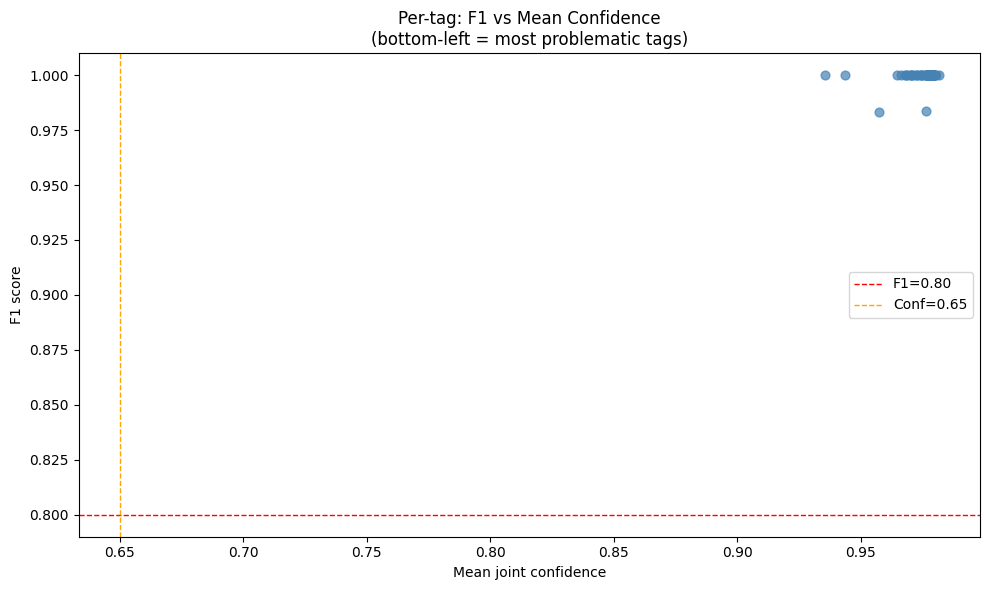

In [10]:
# Per-tag mean joint confidence vs F1
from sklearn.metrics import classification_report as cr

tag_rep = cr(true_tags, hier_preds, output_dict=True, zero_division=0)
tag_conf_mean = test_df_copy.groupby("dpl_tag")["joint_confidence"].mean()

plot_tags = [t for t in tag_conf_mean.index if t in tag_rep]
x_conf = [tag_conf_mean[t] for t in plot_tags]
y_f1   = [tag_rep[t]["f1-score"] for t in plot_tags]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x_conf, y_f1, alpha=0.7, s=40, color="steelblue")
for tag, xc, yf in zip(plot_tags, x_conf, y_f1):
    if yf < 0.80 or xc < 0.65:
        ax.annotate(tag, (xc, yf), fontsize=6, ha="left", va="bottom")
ax.axhline(0.80, color="red",    linestyle="--", linewidth=1, label="F1=0.80")
ax.axvline(0.65, color="orange", linestyle="--", linewidth=1, label="Conf=0.65")
ax.set_xlabel("Mean joint confidence")
ax.set_ylabel("F1 score")
ax.set_title("Per-tag: F1 vs Mean Confidence\n(bottom-left = most problematic tags)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Save Models

In [11]:
SAVE_DIR = "models/hierarchical_conf"
os.makedirs(f"{SAVE_DIR}/l2", exist_ok=True)

joblib.dump(l1_clf,   f"{SAVE_DIR}/l1_group_classifier.joblib")
joblib.dump(le_group, f"{SAVE_DIR}/l1_group_label_encoder.joblib")

for group in l2_clfs:
    safe = group.replace(" ", "_").replace("&", "and").replace(",", "")
    joblib.dump(l2_clfs[group], f"{SAVE_DIR}/l2/{safe}_clf.joblib")
    joblib.dump(l2_les[group],  f"{SAVE_DIR}/l2/{safe}_le.joblib")

with open(f"{SAVE_DIR}/hierarchy.json", "w") as f:
    json.dump(HIERARCHY, f, indent=2)

metrics_out = {
    "accuracy":             float(hier_acc),
    "f1_weighted":          float(hier_f1),
    "l1_accuracy":          float(l1_acc),
    "mean_group_confidence": float(grp_confs.mean()),
    "mean_tag_confidence":   float(tag_confs.mean()),
    "mean_joint_confidence": float(joint_confs.mean()),
    "low_conf_below_0.5":   int((joint_confs < 0.5).sum()),
    "low_conf_below_0.8":   int((joint_confs < 0.8).sum()),
}
with open(f"{SAVE_DIR}/metrics.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

print(f"All models saved to {SAVE_DIR}/")

All models saved to models/hierarchical_conf/


## 9. Inference Helper

In [12]:
def load_hierarchical_conf_classifier(save_dir="models/hierarchical_conf"):
    with open(f"{save_dir}/hierarchy.json") as f:
        hierarchy = json.load(f)
    _l1  = joblib.load(f"{save_dir}/l1_group_classifier.joblib")
    _leg = joblib.load(f"{save_dir}/l1_group_label_encoder.joblib")
    _l2c, _l2l = {}, {}
    for group in hierarchy:
        safe = group.replace(" ", "_").replace("&", "and").replace(",", "")
        if os.path.exists(f"{save_dir}/l2/{safe}_clf.joblib"):
            _l2c[group] = joblib.load(f"{save_dir}/l2/{safe}_clf.joblib")
            _l2l[group] = joblib.load(f"{save_dir}/l2/{safe}_le.joblib")
    return HierarchicalDPLClassifier(_l1, _leg, _l2c, _l2l)


clf = load_hierarchical_conf_classifier()

test_descs = [
    "INV-55234 – Deloitte audit services FY2025",
    "Monthly payroll – March 2026 – Finance",
    "Interest charged on HSBC overdraft – January",
    "Interest received on shareholder loan – April 2025",
    "Google Ads campaign – Q2 2026",
    "Office rent – London HQ – April 2026",
    "Redundancy costs – IT department – 2025",
    "AWS cloud hosting – February subscription",
    "FX loss on USD settlement – AP-78341",
    "Miscellaneous expense",   # intentionally ambiguous
]

results = clf.predict_detailed(test_descs, top_k=3, threshold=0.5)

print(f"{'Description':<50} {'Group':<32} G.Conf  {'Tag':<8} T.Conf  Joint   Status")
print("-" * 120)
for r in results:
    status = "✓ AUTO" if r["accepted"] else "⚠ REVIEW"
    print(f"{r['description'][:49]:<50} {r['group'][:31]:<32} "
          f"{r['group_confidence']:>6.3f}  {r['tag']:<8} "
          f"{r['tag_confidence']:>6.3f}  {r['joint_confidence']:>6.3f}  {status}")

Description                                        Group                            G.Conf  Tag      T.Conf  Joint   Status
------------------------------------------------------------------------------------------------------------------------
INV-55234 – Deloitte audit services FY2025         Professional & External Service   0.996  DPL003    0.982   0.978  ✓ AUTO
Monthly payroll – March 2026 – Finance             Staff & Employment                0.972  DPL068    0.976   0.948  ✓ AUTO
Interest charged on HSBC overdraft – January       Finance & Treasury                0.998  DPL035    0.979   0.976  ✓ AUTO
Interest received on shareholder loan – April 202  Finance & Treasury                0.999  DPL075    0.981   0.980  ✓ AUTO
Google Ads campaign – Q2 2026                      Operational & Administrative      0.997  DPL001    0.983   0.980  ✓ AUTO
Office rent – London HQ – April 2026               Operational & Administrative      0.997  DPL055    0.981   0.978  ✓ AUTO
Redundancy 

In [13]:
# Drill into top-3 tags for one description
desc = "Miscellaneous expense"
detail = clf.predict_detailed([desc], top_k=5, threshold=0.5)[0]

print(f"Description  : {detail['description']}")
print(f"Group        : {detail['group']}  (confidence: {detail['group_confidence']:.4f})")
print(f"Status       : {'✓ AUTO' if detail['accepted'] else '⚠ REVIEW'}")
print()
print(f"{'Rank':<5} {'Tag':<10} {'P(tag|group)':>13} {'Joint P':>9}")
print("-" * 42)
for rank, t in enumerate(detail["top_k_tags"], 1):
    print(f"{rank:<5} {t['tag']:<10} {t['tag_confidence']:>13.4f} {t['joint_confidence']:>9.4f}")

Description  : Miscellaneous expense
Group        : Miscellaneous  (confidence: 0.9935)
Status       : ✓ AUTO

Rank  Tag         P(tag|group)   Joint P
------------------------------------------
1     DPL074            0.9760    0.9697
2     DPL056            0.0064    0.0063
3     DPL059            0.0038    0.0037
4     DPL004            0.0028    0.0028
5     DPL040            0.0021    0.0021


---

## Summary

### Three confidence scores explained

| Score | Formula | Meaning |
|---|---|---|
| `group_confidence` | P(group) | How sure is the model about the accounting category? |
| `tag_confidence` | P(tag \| group) | Given the group is correct, how sure about the specific tag? |
| `joint_confidence` | P(group) × P(tag \| group) | Overall end-to-end confidence — use this for thresholding |

### Recommended thresholds

| `joint_confidence` | Action |
|---|---|
| ≥ 0.90 | Auto-post to ledger |
| 0.50 – 0.90 | Show top-3 suggestions to user |
| < 0.50 | Route to human review |

The **F1 vs Confidence scatter plot** (Section 7) identifies which specific tags have low confidence — those are the ones to improve with more training data.